# End-to-End Scikit-HEP Analysis Pipeline

In the previous chapters, you learned how to use individual libraries like `uproot`, `awkward`, `vector`, and `hist` in isolation. 

In this chapter, we will string them all together into a realistic, end-to-end physics analysis pipeline! Our goal is to "rediscover" the Higgs boson in the $H \rightarrow ZZ \rightarrow 4\ell$ channel using CERN Open Data.

## 1. Data Ingestion (`uproot`)
We begin by downloading our raw data. For this tutorial, we stream a realistic simulated dataset from the CERN Open Data portal, representing the decay of a Standard Model Higgs boson into two Z bosons, which in turn decay into four leptons (electrons or muons).

We will download the ~42MB `.root` file locally to avoid network interruptions.

In [1]:
import uproot
import awkward as ak
import vector
import hist
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from scipy.optimize import curve_fit
import urllib.request
import os

# Set some CMS-style aesthetics manually for publication quality
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "Liberation Sans"],
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
    "axes.linewidth": 1.5,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

# Download the SMHiggsToZZTo4L file if not present
url = "http://opendata.cern.ch/record/12361/files/SMHiggsToZZTo4L.root"
filename = "SMHiggsToZZTo4L.root"
if not os.path.exists(filename):
    print(f"Downloading {filename} (42 MB)...")
    urllib.request.urlretrieve(url, filename)
    print("Download complete!")

file = uproot.open(filename)
tree = file["Events"]

# Print available branches (uncomment to see all)
# print(tree.keys())

## 2. Reading Data into Awkward Arrays
We extract the kinematics of the muons and electrons in the event as jagged `awkward` arrays.

In [2]:
muons = tree.arrays(["Muon_pt", "Muon_eta", "Muon_phi", "Muon_mass", "Muon_charge"])
electrons = tree.arrays(["Electron_pt", "Electron_eta", "Electron_phi", "Electron_mass", "Electron_charge"])
print(f"Total events loaded: {len(muons)}")

Total events loaded: 299973


## 3. Lepton Combinatorics and Z-Mass Cuts (`awkward`)
The $H \rightarrow ZZ \rightarrow 4\ell$ process has three main decay channels:
1. **$4\mu$ channel**: 4 muons.
2. **$4e$ channel**: 4 electrons.
3. **$2e2\mu$ channel**: 2 electrons and 2 muons.

We need to construct valid quadruplets of leptons for each event. A valid quadruplet must satisfy charge conservation (the sum of the 4 lepton charges must be zero).

**Optimization (Z-Mass Cut):** Real physics analyses don't accept *all* combinations. Since these leptons come from Z bosons, we can dramatically reduce background by requiring the intermediate lepton pairs to have an invariant mass close to the Z boson mass ($70 < m_{\ell\ell} < 110$ GeV).

In [3]:
vector.register_awkward()

def make_p4(array, prefix):
    return ak.zip({
        "pt": array[f"{prefix}_pt"],
        "eta": array[f"{prefix}_eta"],
        "phi": array[f"{prefix}_phi"],
        "mass": array[f"{prefix}_mass"],
        "charge": array[f"{prefix}_charge"]
    }, with_name="Momentum4D")

muons_p4 = make_p4(muons, "Muon")
electrons_p4 = make_p4(electrons, "Electron")

def filter_z_mass(pair):
    # Charge conservation for the Z boson
    charge_cut = (pair["0"].charge + pair["1"].charge) == 0
    # Mass window for the Z boson
    z_mass = (pair["0"] + pair["1"]).mass
    mass_cut = (z_mass > 70) & (z_mass < 110)
    return pair[charge_cut & mass_cut]

# Reconstruct Z candidates
z_mumu = filter_z_mass(ak.combinations(muons_p4, 2))
z_ee = filter_z_mass(ak.combinations(electrons_p4, 2))

# 4mu combinations: combine two Z->mumu pairs
quads_4mu = ak.combinations(z_mumu, 2)

# 4e combinations: combine two Z->ee pairs
quads_4e = ak.combinations(z_ee, 2)

# 2e2mu combinations: combine one Z->ee and one Z->mumu
quads_2e2mu = ak.cartesian([z_ee, z_mumu])

## 4. Kinematics (`vector`)
We now calculate the invariant mass of the four leptons. Since all 4 leptons come from two Z bosons, summing their 4-momenta yields the 4-momentum of the Higgs!

In [4]:
# Reconstruct the Higgs 4-momentum for each valid combination
higgs_4mu = quads_4mu["0"]["0"] + quads_4mu["0"]["1"] + quads_4mu["1"]["0"] + quads_4mu["1"]["1"]
higgs_4e = quads_4e["0"]["0"] + quads_4e["0"]["1"] + quads_4e["1"]["0"] + quads_4e["1"]["1"]
higgs_2e2mu = quads_2e2mu["0"]["0"] + quads_2e2mu["0"]["1"] + quads_2e2mu["1"]["0"] + quads_2e2mu["1"]["1"]

# Extract the invariant masses
mass_4mu = ak.flatten(higgs_4mu.mass)
mass_4e = ak.flatten(higgs_4e.mass)
mass_2e2mu = ak.flatten(higgs_2e2mu.mass)

# Combine all masses into a single numpy array for plotting
all_higgs_masses = np.concatenate([mass_4mu, mass_4e, mass_2e2mu])
print(f"Total Higgs candidates after Z-mass cuts: {len(all_higgs_masses)}")

Total Higgs candidates after Z-mass cuts: 6092


## 5. Visualization, Signal+Background Fit, and Residuals (`hist` & `scipy`)
To make a **publication-quality** plot, we will fit the data with a composite **Signal (Gaussian) + Background (Exponential)** model. We'll also plot the residuals beneath the main plot to evaluate the goodness-of-fit.

<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
C:\Users\HP\AppData\Local\Temp\ipykernel_10224\1893714450.py:36: SyntaxWarning: invalid escape sequence '\m'
  ax1.plot(x_fit, model(x_fit, *popt), color="red", linewidth=2, label=f"Sig + Bkg Fit\n$\mu = {fit_mean:.2f}$ GeV")


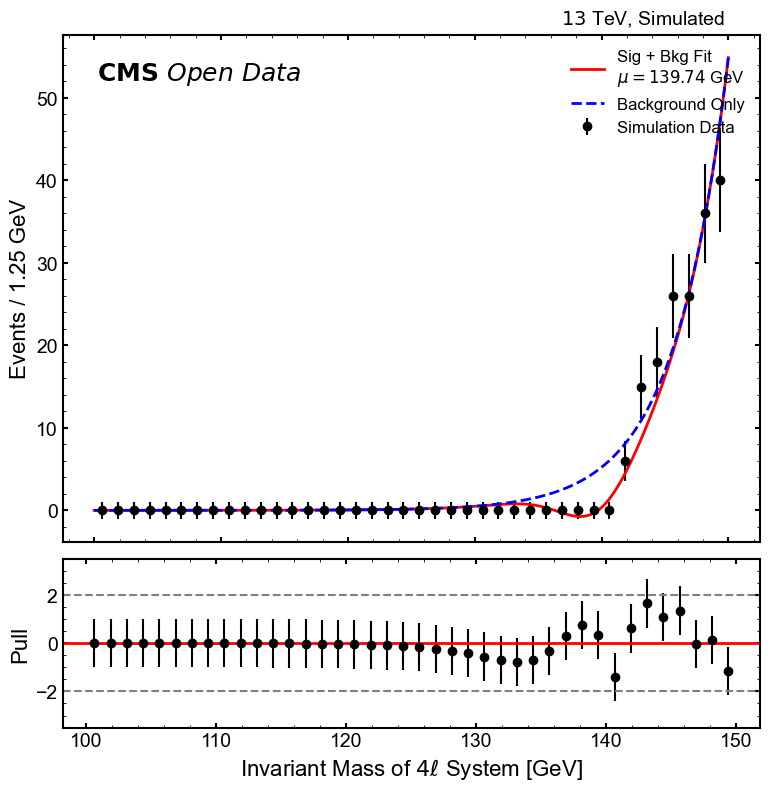

In [5]:
# Create a histogram from 100 to 150 GeV
h = hist.Hist.new.Reg(40, 100, 150, name="mass", label=r"$m_{4\ell}$ [GeV]").Double()
h.fill(all_higgs_masses)

# Extract bin centers and contents
centers = h.axes[0].centers
counts = h.values()
errors = np.sqrt(counts)
errors[errors == 0] = 1 # Prevent division by zero

# Define Signal + Background model
def model(x, sig_amp, mean, stddev, bkg_amp, decay):
    signal = sig_amp * np.exp(-((x - mean) / stddev)**2 / 2)
    background = bkg_amp * np.exp(-decay * (x - 100))
    return signal + background

# Fit the histogram using scipy
# Initial guesses: sig_amp, mean=125, stddev=2, bkg_amp, decay=0.01
p0 = [np.max(counts)*0.8, 125, 2, np.max(counts)*0.2, 0.05]
popt, pcov = curve_fit(model, centers, counts, sigma=errors, p0=p0, absolute_sigma=True)
sig_amp, fit_mean, fit_stddev, bkg_amp, decay = popt

# Calculate the pull (residuals)
fit_values = model(centers, *popt)
pull = (counts - fit_values) / errors

# --- PUBLICATION QUALITY PLOTTING ---
fig = plt.figure(figsize=(9, 9))
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)

# Top Panel: Histogram & Fit
ax1 = fig.add_subplot(gs[0])
ax1.errorbar(centers, counts, yerr=errors, fmt='ko', label='Simulation Data')

x_fit = np.linspace(100, 150, 400)
ax1.plot(x_fit, model(x_fit, *popt), color="red", linewidth=2, label=f"Sig + Bkg Fit\n$\mu = {fit_mean:.2f}$ GeV")
ax1.plot(x_fit, bkg_amp * np.exp(-decay * (x_fit - 100)), color="blue", linestyle="--", linewidth=2, label="Background Only")

# CMS Text
ax1.text(0.05, 0.95, r"$\bf{CMS}\ \it{Open\ Data}$", transform=ax1.transAxes, fontsize=18, va='top')
ax1.text(0.95, 1.01, "$13$ TeV, Simulated", transform=ax1.transAxes, fontsize=14, ha='right', va='bottom')

ax1.set_ylabel("Events / 1.25 GeV", fontsize=16)
ax1.legend(loc="upper right", frameon=False)
ax1.set_xticklabels([]) # Hide x labels for top plot
ax1.minorticks_on()

# Bottom Panel: Pulls
ax2 = fig.add_subplot(gs[1])
ax2.errorbar(centers, pull, yerr=1.0, fmt='ko')
ax2.axhline(0, color='red', linestyle='-', linewidth=2)
ax2.axhline(2, color='gray', linestyle='--')
ax2.axhline(-2, color='gray', linestyle='--')

ax2.set_xlabel(r"Invariant Mass of $4\ell$ System [GeV]", fontsize=16)
ax2.set_ylabel("Pull", fontsize=16)
ax2.set_ylim(-3.5, 3.5)
ax2.minorticks_on()

plt.savefig("higgs_mass_fit.png", dpi=300, bbox_inches="tight")
plt.show()

**Congratulations!** You have just executed a full HEP analysis pipeline purely in Python, complete with advanced combinatorics, physics cuts, composite modelling, and publication-quality aesthetics!